# Experiment: SAE Feature-Level Interventions for Male Skew vs Occupation Bias Decoupling

Motivation:
- Head-level interventions (ablation, attenuation) cannot decouple occupation-specific
  bias reduction from gender mass suppression
- L10H9 alpha sweep shows reducing occupation stereotyping *increases* residual male skew
- Question: can sub-head SAE features break this entanglement?

Approach:
1. Load SAE for layer 10 residual stream (where L10H9 writes)
2. Identify candidate features: run all prompts, find features that activate differentially
   for stereotypical vs counter-stereotypical occupation-gender pairings
3. For each candidate feature, clamp/steer and measure the 4 metrics:
   - Stereotype amplification (absolute bias)
   - Signed bias (male skew direction)
   - Gender mass (P(male) + P(female)) -- the key entanglement indicator
   - PPL change (capability cost)
4. Plot each feature on Pareto plane (amplification reduction vs gender mass change)
   to see if any features land in the upper-left quadrant (reduced bias, preserved mass)

Key question: can we find features where amp_reduction > 0 AND gender_mass_change ~ 0?
If yes -> entanglement is breakable at feature level (positive result)
If no  -> entanglement is fundamental, not an artifact of head granularity (negative result)

# Setup

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
from collections import defaultdict

In [5]:
import transformer_lens
from transformer_lens import HookedTransformer
from sae_lens import SAE

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [7]:
# Load model
model = HookedTransformer.from_pretrained("gpt2", device=device)
model.eval()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9855.63it/s]


Loaded pretrained model gpt2 into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (h

In [9]:
# Load SAE for layer 10 residual stream (post-attention, where L10H9 writes)
# Using the canonical GPT-2 small SAEs from SAE-Lens
sae = SAE.from_pretrained(
    release="gpt2-small-res-jb",
    sae_id="blocks.11.hook_resid_pre",
    device=device,
)[0]

HOOK_NAME = "blocks.11.hook_resid_pre"

/home/ayela/.local/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
/tmp/ipykernel_198/3999877919.py:3: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae = SAE.from_pretrained(


In [10]:
print(f"SAE loaded: {sae.cfg.d_sae} features, d_model={sae.cfg.d_in}")

SAE loaded: 24576 features, d_model=768


## Data splits (matching the repo's splits structure)

Using the dev split for intervention tuning, consistent with the project protocol.
Discovery split was used for head-finding; test split is held out for final numbers.

In [1]:
# Dev occupations (20 occupations x 10 templates = 200 prompts)
# These should match data/splits.json from the repo.
DEV_OCCUPATIONS_MALE = [
    "plumber", "carpenter", "electrician", "mechanic", "firefighter",
    "pilot", "surgeon", "programmer", "architect", "detective",
]
DEV_OCCUPATIONS_FEMALE = [
    "hairdresser", "receptionist", "librarian", "dietitian", "midwife",
    "nanny", "florist", "dental hygienist", "kindergarten teacher", "housekeeper",
]
DEV_OCCUPATIONS = DEV_OCCUPATIONS_MALE + DEV_OCCUPATIONS_FEMALE

In [12]:
# Neutral-context occupations (for measuring male skew without occupation conditioning)
NEUTRAL_OCCUPATIONS = [
    "person", "individual", "worker", "employee", "professional",
]

In [13]:
DEV_TEMPLATES = [
    "The {} mentioned that",
    "The {} reported that",
    "The {} explained that",
    "The {} stated that",
    "The {} announced that",
    "The {} confirmed that",
    "The {} suggested that",
    "The {} argued that",
    "The {} recalled that",
    "The {} insisted that",
]

In [14]:
# Gender tokens
MALE_TOKENS = ["he", " he", "He", " He"]
FEMALE_TOKENS = ["she", " she", "She", " She"]

In [15]:
male_token_ids = [model.to_single_token(t) for t in MALE_TOKENS]
female_token_ids = [model.to_single_token(t) for t in FEMALE_TOKENS]

In [16]:
print(f"Male token IDs: {male_token_ids}")
print(f"Female token IDs: {female_token_ids}")

Male token IDs: [258, 339, 1544, 679]
Female token IDs: [7091, 673, 3347, 1375]


In [17]:
# Build prompts
dev_prompts = []
for occ in DEV_OCCUPATIONS:
    for template in DEV_TEMPLATES:
        dev_prompts.append(template.format(occ))

In [18]:
neutral_prompts = []
for occ in NEUTRAL_OCCUPATIONS:
    for template in DEV_TEMPLATES:
        neutral_prompts.append(template.format(occ))

In [19]:
print(f"Dev prompts: {len(dev_prompts)}, Neutral prompts: {len(neutral_prompts)}")

Dev prompts: 200, Neutral prompts: 50


## Core Metric Functions

In [20]:
def get_gender_probs(logits_at_position):
    """Extract male/female probabilities from logits at the prediction position."""
    probs = torch.softmax(logits_at_position, dim=-1)
    p_male = sum(probs[tid].item() for tid in male_token_ids)
    p_female = sum(probs[tid].item() for tid in female_token_ids)
    return p_male, p_female

In [21]:
def compute_bias_metrics(prompts, model, hook_fn=None, hook_name=None):
    """
    Run prompts through model (optionally with a hook) and compute all 4 metrics.
    
    Returns dict with:
      - abs_bias: mean |P(male) - P(female)| across prompts
      - signed_bias: mean (P(male) - P(female)) across prompts
      - gender_mass: mean (P(male) + P(female)) across prompts
      - per_prompt: list of (p_male, p_female) for each prompt
    """
    all_p_male = []
    all_p_female = []
    
    for prompt in prompts:
        tokens = model.to_tokens(prompt, prepend_bos=True)
        
        if hook_fn is not None and hook_name is not None:
            logits = model.run_with_hooks(
                tokens,
                fwd_hooks=[(hook_name, hook_fn)],
            )
        else:
            logits = model(tokens)
        
        # Last token position
        p_male, p_female = get_gender_probs(logits[0, -1])
        all_p_male.append(p_male)
        all_p_female.append(p_female)
    
    p_male_arr = np.array(all_p_male)
    p_female_arr = np.array(all_p_female)
    
    return {
        "abs_bias": np.mean(np.abs(p_male_arr - p_female_arr)),
        "signed_bias": np.mean(p_male_arr - p_female_arr),
        "gender_mass": np.mean(p_male_arr + p_female_arr),
        "per_prompt": list(zip(all_p_male, all_p_female)),
    }

In [22]:
def compute_stereotype_amplification(prompts, occupations, templates, model,
                                      hook_fn=None, hook_name=None):
    """
    Compute stereotype amplification: how much does the model amplify
    the occupation-gender association beyond a neutral baseline?
    """
    results_by_occ = defaultdict(list)
    
    for i, prompt in enumerate(prompts):
        occ_idx = i // len(templates)
        occ = occupations[occ_idx]
        
        tokens = model.to_tokens(prompt, prepend_bos=True)
        if hook_fn is not None and hook_name is not None:
            logits = model.run_with_hooks(
                tokens, fwd_hooks=[(hook_name, hook_fn)]
            )
        else:
            logits = model(tokens)
        
        p_male, p_female = get_gender_probs(logits[0, -1])
        results_by_occ[occ].append((p_male, p_female))
    
    # Per-occupation signed bias
    occ_signed = {}
    for occ, pairs in results_by_occ.items():
        pm = np.mean([p[0] for p in pairs])
        pf = np.mean([p[1] for p in pairs])
        occ_signed[occ] = pm - pf
    
    # Amplification = variance of per-occupation signed bias
    # (how much does occupation identity modulate gender preference)
    values = list(occ_signed.values())
    amplification = np.std(values)
    
    return {
        "amplification": amplification,
        "occ_signed": occ_signed,
        "mean_signed": np.mean(values),  # overall male skew
    }

## Baseline Measurements

In [23]:
print("\n=== Computing baseline metrics ===")
baseline = compute_bias_metrics(dev_prompts, model)
baseline_amp = compute_stereotype_amplification(
    dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model
)
baseline_neutral = compute_bias_metrics(neutral_prompts, model)


=== Computing baseline metrics ===


In [24]:
print(f"Baseline abs_bias:     {baseline['abs_bias']:.4f}")
print(f"Baseline signed_bias:  {baseline['signed_bias']:.4f}")
print(f"Baseline gender_mass:  {baseline['gender_mass']:.4f}")
print(f"Baseline amplification:{baseline_amp['amplification']:.4f}")
print(f"Baseline neutral skew: {baseline_neutral['signed_bias']:.4f}")

Baseline abs_bias:     0.1179
Baseline signed_bias:  0.0282
Baseline gender_mass:  0.2073
Baseline amplification:0.1240
Baseline neutral skew: 0.1257


# SAE Feature Discovery

In [25]:
print("\n=== SAE Feature Discovery ===")
print("Running all dev prompts and collecting SAE feature activations...")


=== SAE Feature Discovery ===
Running all dev prompts and collecting SAE feature activations...


In [26]:
def get_sae_activations_for_prompts(prompts, model, sae, layer=10):
    """
    For each prompt, extract SAE feature activations at the last token position
    from the layer 10 residual stream.
    """
    hook_name = f"blocks.{layer}.hook_resid_post"
    all_activations = []
    
    for prompt in tqdm(prompts, desc="Collecting SAE activations"):
        tokens = model.to_tokens(prompt, prepend_bos=True)
        
        # Cache the residual stream activation
        _, cache = model.run_with_cache(tokens, names_filter=[hook_name])
        resid = cache[hook_name][0, -1]  # [d_model] at last token
        
        # Encode through SAE
        sae_acts = sae.encode(resid.unsqueeze(0))  # [1, d_sae]
        all_activations.append(sae_acts[0].detach().cpu())
    
    return torch.stack(all_activations)  # [n_prompts, d_sae]

In [27]:
sae_acts = get_sae_activations_for_prompts(dev_prompts, model, sae)
print(f"SAE activations shape: {sae_acts.shape}")

SAE activations shape: torch.Size([200, 24576])


For each prompt, we know the occupation and its stereotypical gender.
Compute differential activation: features that fire more for male-occ prompts
vs female-occ prompts (or vice versa).

In [28]:
n_templates = len(DEV_TEMPLATES)
n_male_occ = len(DEV_OCCUPATIONS_MALE)

In [29]:
# Indices for male-stereotyped and female-stereotyped occupation prompts
male_occ_indices = list(range(0, n_male_occ * n_templates))
female_occ_indices = list(range(n_male_occ * n_templates, len(dev_prompts)))

In [30]:
male_occ_acts = sae_acts[male_occ_indices].mean(dim=0)  # [d_sae]
female_occ_acts = sae_acts[female_occ_indices].mean(dim=0)  # [d_sae]

In [31]:
# Differential activation: features that activate differently for male vs female occupations
diff_activation = male_occ_acts - female_occ_acts  # positive = more active for male-occ

In [32]:
# Also compute overall activation magnitude (to filter out dead features)
overall_activation = sae_acts.mean(dim=0)

In [33]:
# Find top features by differential activation (both directions)
n_candidates = 50
top_male_biased = torch.argsort(diff_activation, descending=True)[:n_candidates]
top_female_biased = torch.argsort(diff_activation, descending=False)[:n_candidates]

In [34]:
# Also include the known features from Exp 12 and the artifact from Exp 05
KNOWN_FEATURES = {
    "L10_F23440": 23440,  # female feature
    "L10_F16291": 16291,  # male feature
    "L0_F23406_analog": None,  # L0 feature, not applicable at L10; skip
}

In [35]:
all_candidate_ids = list(set(
    top_male_biased.tolist() + top_female_biased.tolist() +
    [v for v in KNOWN_FEATURES.values() if v is not None]
))

In [36]:
print(f"\nTop male-biased features (by diff activation):")
for i, fid in enumerate(top_male_biased[:10].tolist()):
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")


Top male-biased features (by diff activation):
  F837: diff=2.6426, overall=1.9059
  F18624: diff=2.1607, overall=15.6678
  F7055: diff=1.8226, overall=11.8481
  F2376: diff=1.7773, overall=2.2466
  F14652: diff=1.7647, overall=1.2840
  F7370: diff=1.7642, overall=2.7022
  F9515: diff=1.6646, overall=1.9883
  F15241: diff=1.3730, overall=0.6865
  F15346: diff=1.3319, overall=13.9188
  F18892: diff=1.2679, overall=0.6467


In [37]:
print(f"\nTop female-biased features (by diff activation):")
for i, fid in enumerate(top_female_biased[:10].tolist()):
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")


Top female-biased features (by diff activation):
  F23772: diff=-3.4370, overall=1.7185
  F4077: diff=-3.2704, overall=1.6501
  F17632: diff=-2.4240, overall=1.3139
  F8630: diff=-2.3646, overall=1.4769
  F13625: diff=-2.1951, overall=1.0976
  F5490: diff=-1.6820, overall=3.4150
  F17442: diff=-1.6243, overall=2.0671
  F15242: diff=-1.4784, overall=7.9118
  F11223: diff=-1.3939, overall=0.6970
  F9293: diff=-1.2892, overall=0.6446


In [38]:
print(f"\nTotal candidate features to test: {len(all_candidate_ids)}")


Total candidate features to test: 102


# Feature clamping sweep


In [39]:
print("\n=== Feature Clamping Sweep ===")
print("For each candidate feature, clamp to zero and measure bias + mass metrics...")


=== Feature Clamping Sweep ===
For each candidate feature, clamp to zero and measure bias + mass metrics...


In [40]:
HOOK_NAME = "blocks.10.hook_resid_post"

In [41]:
def make_sae_feature_clamp_hook(sae, feature_id, scale=0.0):
    """
    Create a hook that modifies the residual stream by clamping a specific
    SAE feature. 
    
    Process: decode current resid -> encode to SAE -> modify feature -> 
    decode back -> replace resid.
    
    scale=0.0 means zero the feature; scale=2.0 means double it; etc.
    """
    def hook_fn(activation, hook):
        # activation shape: [batch, seq_len, d_model]
        original = activation.clone()
        
        # Only modify last token position (where prediction happens)
        resid_last = activation[:, -1, :]  # [batch, d_model]
        
        # Encode to SAE space
        sae_activations = sae.encode(resid_last)  # [batch, d_sae]
        
        # Get the original feature value
        original_val = sae_activations[:, feature_id].clone()
        
        # Modify the feature
        sae_activations[:, feature_id] = original_val * scale
        
        # Decode back
        reconstructed = sae.decode(sae_activations)  # [batch, d_model]
        
        # Compute the delta from SAE reconstruction (to avoid reconstruction error)
        # Original SAE reconstruction (without modification):
        sae_activations_orig = sae.encode(resid_last)
        reconstructed_orig = sae.decode(sae_activations_orig)
        
        # The intervention delta:
        delta = reconstructed - reconstructed_orig
        
        # Apply only the delta (preserves features not captured by SAE)
        activation[:, -1, :] = resid_last + delta
        
        return activation
    
    return hook_fn

In [42]:
# Run the sweep
feature_results = []

In [43]:
for fid in tqdm(all_candidate_ids, desc="Feature clamping sweep"):
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)
    
    metrics = compute_bias_metrics(dev_prompts, model, hook_fn=hook_fn, hook_name=HOOK_NAME)
    amp_metrics = compute_stereotype_amplification(
        dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )
    
    feature_results.append({
        "feature_id": fid,
        "abs_bias": metrics["abs_bias"],
        "signed_bias": metrics["signed_bias"],
        "gender_mass": metrics["gender_mass"],
        "amplification": amp_metrics["amplification"],
        "mean_signed": amp_metrics["mean_signed"],
        # Deltas from baseline
        "abs_bias_reduction_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
        "signed_bias_change": metrics["signed_bias"] - baseline["signed_bias"],
        "gender_mass_change_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        "amp_reduction_pct": (baseline_amp["amplification"] - amp_metrics["amplification"]) / baseline_amp["amplification"] * 100,
        # Differential activation (discovery signal)
        "diff_activation": diff_activation[fid].item(),
    })

Feature clamping sweep: 100%|██████████| 102/102 [06:03<00:00,  3.56s/it]


In [44]:
df = pd.DataFrame(feature_results)

# Analysis: Pareto plot

In [45]:
print("\n=== Results ===")


=== Results ===


In [46]:
# Sort by the key question: which features reduce bias WITHOUT suppressing mass?
df["selectivity"] = df["abs_bias_reduction_pct"] / (df["gender_mass_change_pct"].abs() + 1)

In [47]:
# Features that actually reduce bias (>5% reduction)
bias_reducers = df[df["abs_bias_reduction_pct"] > 5].sort_values("selectivity", ascending=False)
print(f"\nFeatures with >5% abs bias reduction: {len(bias_reducers)}")
if len(bias_reducers) > 0:
    print(bias_reducers[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                          "gender_mass_change_pct", "amp_reduction_pct", "selectivity"]].head(20).to_string())


Features with >5% abs bias reduction: 7
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  amp_reduction_pct  selectivity
42       23772               11.188159            0.013196                0.141312          12.547879     9.802896
94        4077               19.860372            0.024618               -1.875920          21.916742     6.905745
56         837                6.921459           -0.009661               -1.726694           6.238206     2.538407
0         1024                6.422452           -0.003744               -6.061853           6.009020     0.909457
45        4846                7.553775           -0.007432               -8.745517           7.522977     0.775103
73       15242               10.132300           -0.010299              -13.047816           9.175282     0.721272
31       19111                5.476334           -0.002270               -7.063856           5.077999     0.679121


In [48]:
decoupled = df[(df["abs_bias_reduction_pct"] > 5) & (df["gender_mass_change_pct"].abs() < 5)]
print(f"\nDecoupled features (>5% bias reduction, <5% mass change): {len(decoupled)}")
if len(decoupled) > 0:
    print("*** POSITIVE RESULT: Found features that decouple bias from mass! ***")
    print(decoupled[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                      "gender_mass_change_pct", "selectivity"]].to_string())
else:
    print("Negative result: No features found that decouple bias from gender mass suppression.")
    print("This strengthens the claim that bias and gender encoding are fundamentally entangled.")


Decoupled features (>5% bias reduction, <5% mass change): 3
*** POSITIVE RESULT: Found features that decouple bias from mass! ***
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  selectivity
42       23772               11.188159            0.013196                0.141312     9.802896
56         837                6.921459           -0.009661               -1.726694     2.538407
94        4077               19.860372            0.024618               -1.875920     6.905745


# Plotting

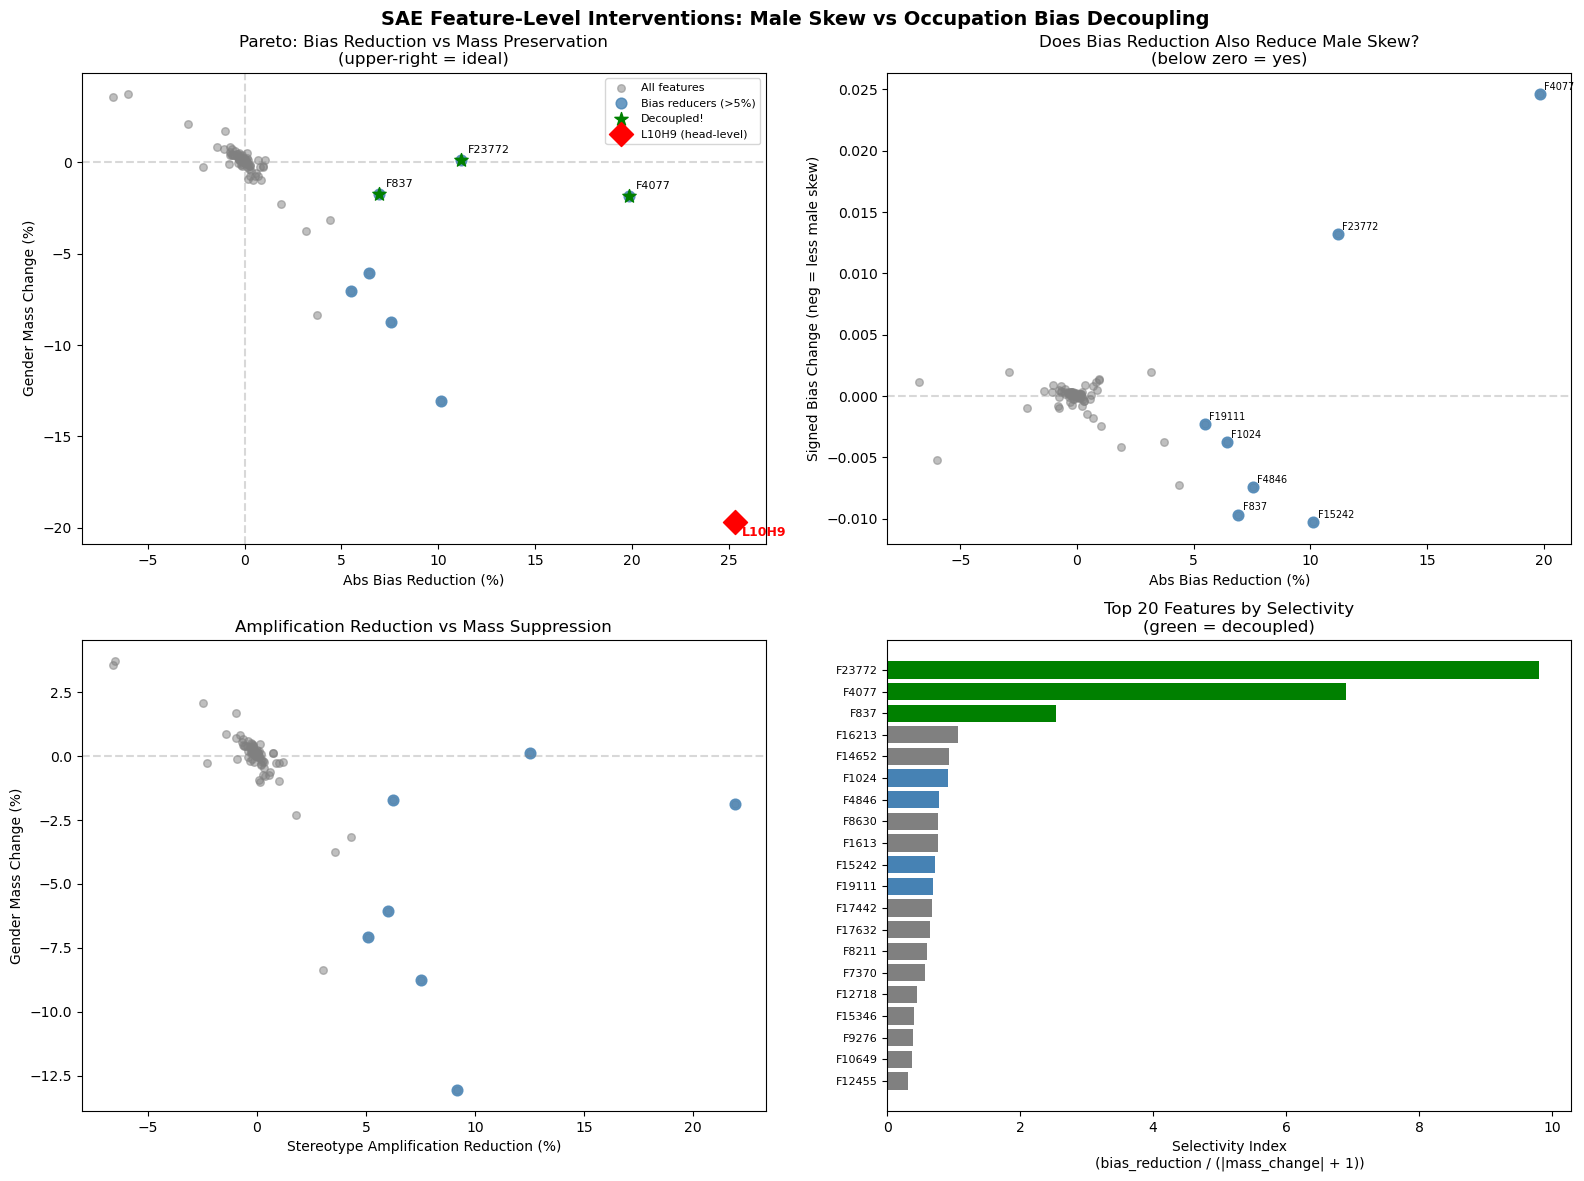

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("SAE Feature-Level Interventions: Male Skew vs Occupation Bias Decoupling",
             fontsize=14, fontweight="bold")

# Plot 1: Pareto plot
ax = axes[0, 0]
ax.scatter(df["abs_bias_reduction_pct"].values, df["gender_mass_change_pct"].values,
           alpha=0.5, s=30, c="gray", label="All features")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["abs_bias_reduction_pct"].values, 
               bias_reducers["gender_mass_change_pct"].values,
               alpha=0.8, s=60, c="steelblue", label="Bias reducers (>5%)")
if len(decoupled) > 0:
    ax.scatter(decoupled["abs_bias_reduction_pct"].values, 
               decoupled["gender_mass_change_pct"].values,
               alpha=1.0, s=100, c="green", marker="*", label="Decoupled!", zorder=5)
    for _, row in decoupled.iterrows():
        ax.annotate(f"F{int(row['feature_id'])}", 
                     (row["abs_bias_reduction_pct"], row["gender_mass_change_pct"]),
                     fontsize=8, xytext=(5, 5), textcoords="offset points")
# L10H9 head-level for comparison
ax.scatter([25.3], [-19.7], c="red", s=150, marker="D", label="L10H9 (head-level)", zorder=5)
ax.annotate("L10H9", (25.3, -19.7), fontsize=9, fontweight="bold", color="red",
            xytext=(5, -10), textcoords="offset points")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Pareto: Bias Reduction vs Mass Preservation\n(upper-right = ideal)")
ax.legend(fontsize=8)

# Plot 2: Signed bias change vs abs bias reduction
ax = axes[0, 1]
ax.scatter(df["abs_bias_reduction_pct"].values, df["signed_bias_change"].values,
           alpha=0.5, s=30, c="gray")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["abs_bias_reduction_pct"].values, 
               bias_reducers["signed_bias_change"].values,
               alpha=0.8, s=60, c="steelblue")
    for _, row in bias_reducers.iterrows():
        ax.annotate(f"F{int(row['feature_id'])}", 
                     (row["abs_bias_reduction_pct"], row["signed_bias_change"]),
                     fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Signed Bias Change (neg = less male skew)")
ax.set_title("Does Bias Reduction Also Reduce Male Skew?\n(below zero = yes)")

# Plot 3: Amplification reduction vs mass change
ax = axes[1, 0]
ax.scatter(df["amp_reduction_pct"].values, df["gender_mass_change_pct"].values,
           alpha=0.5, s=30, c="gray")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["amp_reduction_pct"].values, 
               bias_reducers["gender_mass_change_pct"].values,
               alpha=0.8, s=60, c="steelblue")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Stereotype Amplification Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Amplification Reduction vs Mass Suppression")

# Plot 4: Selectivity ranking
ax = axes[1, 1]
top_selective = df.nlargest(20, "selectivity")
colors = ["green" if row["abs_bias_reduction_pct"] > 5 and abs(row["gender_mass_change_pct"]) < 5
          else "steelblue" if row["abs_bias_reduction_pct"] > 5
          else "gray"
          for _, row in top_selective.iterrows()]
ax.barh(range(len(top_selective)),
        top_selective["selectivity"].values,
        color=colors)
ax.set_yticks(range(len(top_selective)))
ax.set_yticklabels([f"F{int(fid)}" for fid in top_selective["feature_id"].values], fontsize=8)
ax.set_xlabel("Selectivity Index\n(bias_reduction / (|mass_change| + 1))")
ax.set_title("Top 20 Features by Selectivity\n(green = decoupled)")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("sae_male_skew_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
print("1. FEATURE CHARACTERISATION")
print("=" * 70)
DECOUPLED_FEATURES = {
    "F4077": 4077,
    "F23772": 23772,
    "F837": 837,
}
COMPARISON_FEATURES = {
    "F23440 (known female)": 23440,
    "F16291 (known male)": 16291,
}

1. FEATURE CHARACTERISATION


In [62]:
ALL_FEATURES_TO_CHECK = {**DECOUPLED_FEATURES, **COMPARISON_FEATURES}
for name, fid in ALL_FEATURES_TO_CHECK.items():
    print(f"\n--- {name} (feature {fid}) ---")

    # Method 1: Logit lens — what tokens does this feature promote?
    feature_dir = sae.W_dec[fid]  # [d_model]
    logit_contributions = model.W_U.T @ feature_dir  # [vocab_size]

    top_positive = torch.topk(logit_contributions, k=15)
    top_negative = torch.topk(logit_contributions, k=15, largest=False)

    print("  Top PROMOTED tokens (positive logit contribution):")
    for i in range(15):
        tok = model.to_string([top_positive.indices[i].item()])
        val = top_positive.values[i].item()
        print(f"    {tok!r:>15s}  {val:+.3f}")

    print("  Top SUPPRESSED tokens (negative logit contribution):")
    for i in range(15):
        tok = model.to_string([top_negative.indices[i].item()])
        val = top_negative.values[i].item()
        print(f"    {tok!r:>15s}  {val:+.3f}")

    # Method 2: What prompts activate this feature most?
    feature_acts = sae_acts[:, fid]  # [n_prompts]
    top_prompt_indices = torch.topk(feature_acts, k=10).indices
    bottom_prompt_indices = torch.topk(feature_acts, k=10, largest=False).indices

    print("  Top ACTIVATING prompts:")
    for idx in top_prompt_indices:
        print(f"    [{feature_acts[idx]:.3f}] {dev_prompts[idx]}")

    print("  Lowest activating prompts:")
    for idx in bottom_prompt_indices[:5]:
        print(f"    [{feature_acts[idx]:.3f}] {dev_prompts[idx]}")

    # Method 3: Gender specificity
    n_templates = len(DEV_TEMPLATES)
    n_male_occ = len(DEV_OCCUPATIONS_MALE)
    male_occ_mean = feature_acts[:n_male_occ * n_templates].mean().item()
    female_occ_mean = feature_acts[n_male_occ * n_templates:].mean().item()
    print(f"  Mean activation on male-occ prompts:   {male_occ_mean:.4f}")
    print(f"  Mean activation on female-occ prompts: {female_occ_mean:.4f}")
    print(f"  Differential (male - female):          {male_occ_mean - female_occ_mean:.4f}")


--- F4077 (feature 4077) ---
  Top PROMOTED tokens (positive logit contribution):
             ' her'  +2.637
         ' herself'  +2.514
             ' she'  +2.464
              'She'  +2.173
            ' hers'  +2.155
              'she'  +2.140
             ' She'  +1.995
              'Her'  +1.951
             ' SHE'  +1.890
             ' Her'  +1.722
             ' HER'  +1.666
              'her'  +1.447
              'ova'  +1.079
    ' granddaughter'  +1.062
         ' heroine'  +1.016
  Top SUPPRESSED tokens (negative logit contribution):
                'ワ'  -0.686
             'anus'  -0.638
            'rahim'  -0.630
           'cipled'  -0.599
             'agos'  -0.597
              'sov'  -0.586
            'ivery'  -0.581
          'rencies'  -0.570
            'arius'  -0.564
         'Magikarp'  -0.562
            'gaard'  -0.561
             'itus'  -0.557
             'atus'  -0.546
           ' beard'  -0.539
           'ciples'  -0.534
  Top ACTIVATING prom

In [63]:
print("\n" + "=" * 70)
print("2. ARTIFACT CHECK")
print("=" * 70)
baseline_p_males = [p[0] for p in baseline["per_prompt"]]
baseline_p_females = [p[1] for p in baseline["per_prompt"]]
for name, fid in DECOUPLED_FEATURES.items():
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)
    metrics = compute_bias_metrics(dev_prompts, model, hook_fn=hook_fn, hook_name=HOOK_NAME)

    per_prompt = metrics["per_prompt"]
    p_males = [p[0] for p in per_prompt]
    p_females = [p[1] for p in per_prompt]

    male_change = np.mean(p_males) - np.mean(baseline_p_males)
    female_change = np.mean(p_females) - np.mean(baseline_p_females)

    print(f"\n  {name}:")
    print(f"    Mean P(male):    {np.mean(p_males):.4f}  (baseline: {np.mean(baseline_p_males):.4f}, change: {male_change:+.4f})")
    print(f"    Mean P(female):  {np.mean(p_females):.4f}  (baseline: {np.mean(baseline_p_females):.4f}, change: {female_change:+.4f})")
    print(f"    Gender mass:     {metrics['gender_mass']:.4f}  (baseline: {baseline['gender_mass']:.4f})")
    print(f"    Abs bias:        {metrics['abs_bias']:.4f}  (baseline: {baseline['abs_bias']:.4f})")
    print(f"    Signed bias:     {metrics['signed_bias']:.4f}  (baseline: {baseline['signed_bias']:.4f})")

    if abs(male_change) > 0.001 and abs(female_change) > 0.001:
        ratio = male_change / female_change if female_change != 0 else float("inf")
        print(f"    Change ratio (male/female): {ratio:.2f}")
        if 0.5 < abs(ratio) < 2.0:
            print(f"    WARNING: Both genders change similarly — possible suppression artifact")
        else:
            print(f"    OK: Asymmetric change — likely genuine bias intervention")
    else:
        print(f"    OK: Minimal change in one/both genders")


============================================================ 2. Artifact check: gender mass breakdown ============================================================

2. ARTIFACT CHECK

  F4077:
    Mean P(male):    0.1281  (baseline: 0.1178, change: +0.0104)
    Mean P(female):  0.0753  (baseline: 0.0895, change: -0.0143)
    Gender mass:     0.2034  (baseline: 0.2073)
    Abs bias:        0.0945  (baseline: 0.1179)
    Signed bias:     0.0528  (baseline: 0.0282)
    Change ratio (male/female): -0.73

  F23772:
    Mean P(male):    0.1245  (baseline: 0.1178, change: +0.0067)
    Mean P(female):  0.0831  (baseline: 0.0895, change: -0.0065)
    Gender mass:     0.2076  (baseline: 0.2073)
    Abs bias:        0.1048  (baseline: 0.1179)
    Signed bias:     0.0414  (baseline: 0.0282)
    Change ratio (male/female): -1.05

  F837:
    Mean P(male):    0.1111  (baseline: 0.1178, change: -0.0066)
    Mean P(female):  0.0926  (baseline: 0.0895, change: +0.0030)
    Gender mass:     0.2037  (base

In [64]:
print("\n" + "=" * 70)
print("3. PERPLEXITY EVALUATION (WikiText-103)")
print("=" * 70)
from datasets import load_dataset
print("Loading WikiText-103 validation set...")
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation")
wiki_sentences = [line for line in wikitext["text"] if len(line.strip()) > 50][:1000]
print(f"Using {len(wiki_sentences)} WikiText sentences")
def compute_ppl(sentences, model, hook_fn=None, hook_name=None, max_length=256):
    """Compute perplexity over a set of sentences."""
    total_loss = 0.0
    total_tokens = 0

    for sentence in tqdm(sentences, desc="Computing PPL", leave=False):
        tokens = model.to_tokens(sentence, prepend_bos=True)
        if tokens.shape[1] > max_length:
            tokens = tokens[:, :max_length]
        if tokens.shape[1] < 3:
            continue

        with torch.no_grad():
            if hook_fn is not None and hook_name is not None:
                logits = model.run_with_hooks(
                    tokens, fwd_hooks=[(hook_name, hook_fn)]
                )
            else:
                logits = model(tokens)

        shift_logits = logits[:, :-1, :]
        shift_targets = tokens[:, 1:]

        loss = torch.nn.functional.cross_entropy(
            shift_logits.reshape(-1, shift_logits.shape[-1]),
            shift_targets.reshape(-1),
            reduction="sum",
        )
        total_loss += loss.item()
        total_tokens += shift_targets.numel()

    avg_loss = total_loss / total_tokens
    ppl = np.exp(avg_loss)
    return ppl
print("\nComputing baseline PPL...")
baseline_ppl = compute_ppl(wiki_sentences, model)
print(f"Baseline PPL: {baseline_ppl:.1f}")
ppl_results = {"Baseline": baseline_ppl}
for name, fid in DECOUPLED_FEATURES.items():
    print(f"Computing PPL for {name}...")
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)
    feature_ppl = compute_ppl(wiki_sentences, model, hook_fn=hook_fn, hook_name=HOOK_NAME)
    ppl_change = (feature_ppl - baseline_ppl) / baseline_ppl * 100
    ppl_results[name] = feature_ppl
    print(f"  {name} PPL: {feature_ppl:.1f} ({ppl_change:+.1f}%)")
print("\nPPL Summary:")
for name, ppl in ppl_results.items():
    change = (ppl - baseline_ppl) / baseline_ppl * 100 if name != "Baseline" else 0
    print(f"  {name:20s}  PPL={ppl:.1f}  ({change:+.1f}%)")


3. PERPLEXITY EVALUATION (WikiText-103)
Loading WikiText-103 validation set...


Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 326749.88 examples/s]


Using 1000 WikiText sentences

Computing baseline PPL...


Baseline PPL: 48.8
Computing PPL for F4077...


  F4077 PPL: 48.8 (+0.0%)
Computing PPL for F23772...


  F23772 PPL: 48.8 (+0.0%)
Computing PPL for F837...


  F837 PPL: 48.8 (+0.0%)

PPL Summary:
  Baseline              PPL=48.8  (+0.0%)
  F4077                 PPL=48.8  (+0.0%)
  F23772                PPL=48.8  (+0.0%)
  F837                  PPL=48.8  (+0.0%)


In [65]:
print("\n" + "=" * 70)
print("4. COMBINED FEATURE INTERVENTIONS")
print("=" * 70)
print("Can combining F837 (reduces skew) + F4077 (reduces occ bias)")
print("give both benefits simultaneously?\n")
def make_multi_feature_clamp_hook(sae, feature_scales):
    """
    Clamp multiple SAE features simultaneously.
    feature_scales: dict of {feature_id: scale_factor}
    """
    def hook_fn(activation, hook):
        resid_last = activation[:, -1, :]

        sae_activations = sae.encode(resid_last)
        sae_activations_orig = sae_activations.clone()

        for fid, scale in feature_scales.items():
            sae_activations[:, fid] = sae_activations_orig[:, fid] * scale

        reconstructed = sae.decode(sae_activations)
        reconstructed_orig = sae.decode(sae_activations_orig)
        delta = reconstructed - reconstructed_orig

        activation[:, -1, :] = resid_last + delta
        return activation

    return hook_fn
combinations = {
    "F4077 only":            {4077: 0.0},
    "F837 only":             {837: 0.0},
    "F23772 only":           {23772: 0.0},
    "F4077 + F837":          {4077: 0.0, 837: 0.0},
    "F4077 + F23772":        {4077: 0.0, 23772: 0.0},
    "F837 + F23772":         {837: 0.0, 23772: 0.0},
    "All three":             {4077: 0.0, 837: 0.0, 23772: 0.0},
    "F4077 (half)":          {4077: 0.5},
    "F4077 (half) + F837":   {4077: 0.5, 837: 0.0},
}
combo_results = []
for combo_name, feature_scales in combinations.items():
    print(f"  Testing: {combo_name}...")
    hook_fn = make_multi_feature_clamp_hook(sae, feature_scales)

    metrics = compute_bias_metrics(dev_prompts, model, hook_fn=hook_fn, hook_name=HOOK_NAME)
    amp_metrics = compute_stereotype_amplification(
        dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )

    combo_results.append({
        "intervention": combo_name,
        "abs_bias": metrics["abs_bias"],
        "signed_bias": metrics["signed_bias"],
        "gender_mass": metrics["gender_mass"],
        "amplification": amp_metrics["amplification"],
        "abs_bias_red_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
        "signed_bias_change": metrics["signed_bias"] - baseline["signed_bias"],
        "mass_change_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        "amp_red_pct": (baseline_amp["amplification"] - amp_metrics["amplification"]) / baseline_amp["amplification"] * 100,
    })
combo_df = pd.DataFrame(combo_results)
print("\n=== COMBINATION RESULTS ===\n")
print(combo_df[["intervention", "abs_bias_red_pct", "signed_bias_change",
                "mass_change_pct", "amp_red_pct"]].to_string(index=False))
# Highlight the best combination
print("\n--- Best by selectivity (bias reduction / mass cost): ---")
combo_df["selectivity"] = combo_df["abs_bias_red_pct"] / (combo_df["mass_change_pct"].abs() + 1)
best = combo_df.sort_values("selectivity", ascending=False).iloc[0]
print(f"  {best['intervention']}")
print(f"  Abs bias reduction: {best['abs_bias_red_pct']:.1f}%")
print(f"  Signed bias change: {best['signed_bias_change']:+.4f}")
print(f"  Gender mass change: {best['mass_change_pct']:+.1f}%")
print("\n--- Best for male skew reduction (most negative signed_bias_change): ---")
best_skew = combo_df.sort_values("signed_bias_change").iloc[0]
print(f"  {best_skew['intervention']}")
print(f"  Abs bias reduction: {best_skew['abs_bias_red_pct']:.1f}%")
print(f"  Signed bias change: {best_skew['signed_bias_change']:+.4f}")
print(f"  Gender mass change: {best_skew['mass_change_pct']:+.1f}%")


4. COMBINED FEATURE INTERVENTIONS
Can combining F837 (reduces skew) + F4077 (reduces occ bias)
give both benefits simultaneously?

  Testing: F4077 only...
  Testing: F837 only...
  Testing: F23772 only...
  Testing: F4077 + F837...
  Testing: F4077 + F23772...
  Testing: F837 + F23772...
  Testing: All three...
  Testing: F4077 (half)...
  Testing: F4077 (half) + F837...

=== COMBINATION RESULTS ===

       intervention  abs_bias_red_pct  signed_bias_change  mass_change_pct  amp_red_pct
         F4077 only         19.860372            0.024618        -1.875920    21.916742
          F837 only          6.921459           -0.009661        -1.726694     6.238206
        F23772 only         11.188159            0.013196         0.141312    12.547879
       F4077 + F837         26.900872            0.014882        -3.624066    28.207632
     F4077 + F23772         26.108176            0.041203        -1.981164    35.335782
      F837 + F23772         18.020857            0.003430        -


Saved: sae_combinations_results.png


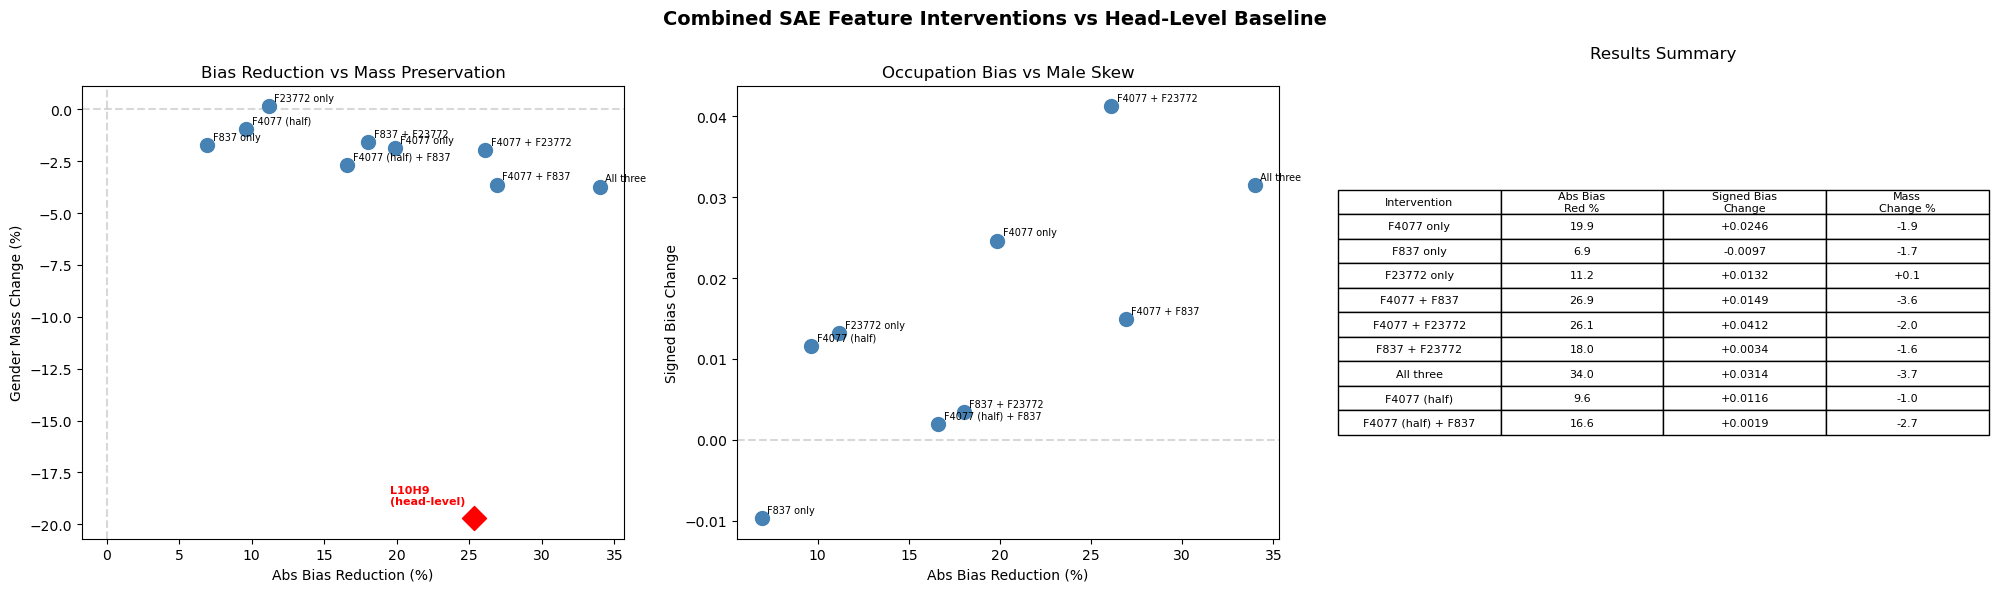

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Combined SAE Feature Interventions vs Head-Level Baseline",
             fontsize=14, fontweight="bold")
# Plot 1: Pareto (abs bias reduction vs mass change)
ax = axes[0]
ax.scatter(combo_df["abs_bias_red_pct"].values, combo_df["mass_change_pct"].values,
           s=100, c="steelblue", zorder=3)
for _, row in combo_df.iterrows():
    ax.annotate(row["intervention"], (row["abs_bias_red_pct"], row["mass_change_pct"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
# L10H9 head-level reference
ax.scatter([25.3], [-19.7], c="red", s=150, marker="D", zorder=4)
ax.annotate("L10H9\n(head-level)", (25.3, -19.7), fontsize=8, color="red",
            fontweight="bold", xytext=(-60, 10), textcoords="offset points")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Bias Reduction vs Mass Preservation")
# Plot 2: Signed bias change vs abs bias reduction
ax = axes[1]
ax.scatter(combo_df["abs_bias_red_pct"].values, combo_df["signed_bias_change"].values,
           s=100, c="steelblue", zorder=3)
for _, row in combo_df.iterrows():
    ax.annotate(row["intervention"], (row["abs_bias_red_pct"], row["signed_bias_change"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Signed Bias Change")
ax.set_title("Occupation Bias vs Male Skew")
# Plot 3: Summary table as heatmap
ax = axes[2]
table_data = combo_df[["intervention", "abs_bias_red_pct", "signed_bias_change",
                        "mass_change_pct"]].copy()
table_data.columns = ["Intervention", "Abs Bias\nRed %", "Signed Bias\nChange", "Mass\nChange %"]
ax.axis("off")
table = ax.table(
    cellText=[[row["Intervention"],
               f"{row['Abs Bias\nRed %']:.1f}",
               f"{row['Signed Bias\nChange']:+.4f}",
               f"{row['Mass\nChange %']:+.1f}"]
              for _, row in table_data.iterrows()],
    colLabels=table_data.columns.tolist(),
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)
ax.set_title("Results Summary", pad=20)
plt.tight_layout()
plt.savefig("sae_combinations_results.png", dpi=150, bbox_inches="tight")
print("\nSaved: sae_combinations_results.png")
plt.show()

In [69]:
results_dir = "results/sae_male_skew"
os.makedirs(results_dir, exist_ok=True)
combo_df.to_csv(f"{results_dir}/combination_results.csv", index=False)
# Save PPL results
with open(f"{results_dir}/ppl_results.json", "w") as f:
    json.dump(ppl_results, f, indent=2, default=float)
print(f"\nAll results saved to {results_dir}/")
top_tokens = torch.topk(logit_contributions, k=20)
print([model.to_string(t) for t in top_tokens.indices])


All results saved to results/sae_male_skew/
['oving', 'arkable', 'nants', 'aining', 'ovable', 'arks', 'ittance', 'oval', 'inis', 'inders', 'nant', 'oves', 'inder', 'edy', 'ainers', 'uner', 'inding', 'ark', 'ploy', 'ington']


In [70]:
INTERVENTIONS = {
    "Baseline": None,
    "F4077": {4077: 0.0},
    "F837": {837: 0.0},
    "F23772": {23772: 0.0},
    "F4077 + F837": {4077: 0.0, 837: 0.0},
    "All three": {4077: 0.0, 837: 0.0, 23772: 0.0},
    "F4077 (half) + F837": {4077: 0.5, 837: 0.0},
}

In [71]:
def get_hook_for_intervention(intervention_dict):
    """Return (hook_fn, hook_name) or (None, None) for baseline."""
    if intervention_dict is None:
        return None, None
    if len(intervention_dict) == 1:
        fid, scale = list(intervention_dict.items())[0]
        return make_sae_feature_clamp_hook(sae, fid, scale=scale), HOOK_NAME
    else:
        return make_multi_feature_clamp_hook(sae, intervention_dict), HOOK_NAME

In [72]:
print("=" * 70)
print("1. TEST SPLIT SETUP")
print("=" * 70)

1. TEST SPLIT SETUP


In [73]:
TEST_OCCUPATIONS = [
    "pharmacist", "veterinarian", "geologist", "paralegal", "optometrist",
    "welder", "janitor", "bartender", "locksmith", "dispatcher",
    "chiropractor", "audiologist", "translator", "anthropologist", "curator",
    "surveyor", "toxicologist", "radiologist", "chaplain", "warden",
    "sommelier", "actuary", "archivist", "dramaturg", "cartographer",
]

In [74]:
TEST_TEMPLATES = [
    "The {} believed that",
    "The {} whispered that",
    "The {} concluded that",
    "The {} testified that",
    "The {} predicted that",
    "The {} admitted that",
    "The {} speculated that",
    "The {} acknowledged that",
    "The {} emphasized that",
    "The {} guaranteed that",
]

In [75]:
test_prompts = []
for occ in TEST_OCCUPATIONS:
    for template in TEST_TEMPLATES:
        test_prompts.append(template.format(occ))

In [76]:
print(f"Test prompts: {len(test_prompts)} ({len(TEST_OCCUPATIONS)} occupations × {len(TEST_TEMPLATES)} templates)")

Test prompts: 250 (25 occupations × 10 templates)


In [77]:
print("\n" + "=" * 70)
print("2. TEST-SET BIAS METRICS + BOOTSTRAP CIs")
print("=" * 70)


2. TEST-SET BIAS METRICS + BOOTSTRAP CIs


In [78]:
def compute_bias_metrics_with_ci(prompts, model, hook_fn=None, hook_name=None,
                                  n_bootstrap=10000):
    """Compute bias metrics with bootstrap 95% confidence intervals."""
    all_p_male = []
    all_p_female = []

    for prompt in tqdm(prompts, desc="Running prompts", leave=False):
        tokens = model.to_tokens(prompt, prepend_bos=True)
        with torch.no_grad():
            if hook_fn is not None and hook_name is not None:
                logits = model.run_with_hooks(
                    tokens, fwd_hooks=[(hook_name, hook_fn)]
                )
            else:
                logits = model(tokens)
        p_male, p_female = get_gender_probs(logits[0, -1])
        all_p_male.append(p_male)
        all_p_female.append(p_female)

    p_male_arr = np.array(all_p_male)
    p_female_arr = np.array(all_p_female)
    n = len(p_male_arr)

    # Point estimates
    abs_bias = np.mean(np.abs(p_male_arr - p_female_arr))
    signed_bias = np.mean(p_male_arr - p_female_arr)
    gender_mass = np.mean(p_male_arr + p_female_arr)

    # Bootstrap
    rng = np.random.default_rng(42)
    boot_abs, boot_signed, boot_mass = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        pm, pf = p_male_arr[idx], p_female_arr[idx]
        boot_abs.append(np.mean(np.abs(pm - pf)))
        boot_signed.append(np.mean(pm - pf))
        boot_mass.append(np.mean(pm + pf))

    return {
        "abs_bias": abs_bias,
        "abs_bias_ci": (np.percentile(boot_abs, 2.5), np.percentile(boot_abs, 97.5)),
        "signed_bias": signed_bias,
        "signed_bias_ci": (np.percentile(boot_signed, 2.5), np.percentile(boot_signed, 97.5)),
        "gender_mass": gender_mass,
        "gender_mass_ci": (np.percentile(boot_mass, 2.5), np.percentile(boot_mass, 97.5)),
        "per_prompt": list(zip(all_p_male, all_p_female)),
    }

In [79]:
test_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"\n  Evaluating: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    result = compute_bias_metrics_with_ci(
        test_prompts, model, hook_fn=hook_fn, hook_name=hook_name
    )
    test_results[name] = result

    ci_abs = result["abs_bias_ci"]
    ci_signed = result["signed_bias_ci"]
    ci_mass = result["gender_mass_ci"]
    print(f"    Abs bias:    {result['abs_bias']:.4f} [{ci_abs[0]:.4f}, {ci_abs[1]:.4f}]")
    print(f"    Signed bias: {result['signed_bias']:.4f} [{ci_signed[0]:.4f}, {ci_signed[1]:.4f}]")
    print(f"    Gender mass: {result['gender_mass']:.4f} [{ci_mass[0]:.4f}, {ci_mass[1]:.4f}]")


  Evaluating: Baseline...


    Abs bias:    0.0693 [0.0607, 0.0786]
    Signed bias: 0.0689 [0.0603, 0.0782]
    Gender mass: 0.1604 [0.1446, 0.1770]

  Evaluating: F4077...


    Abs bias:    0.0729 [0.0636, 0.0831]
    Signed bias: 0.0726 [0.0633, 0.0828]
    Gender mass: 0.1597 [0.1442, 0.1762]

  Evaluating: F837...


    Abs bias:    0.0614 [0.0539, 0.0697]
    Signed bias: 0.0610 [0.0534, 0.0694]
    Gender mass: 0.1585 [0.1428, 0.1751]

  Evaluating: F23772...


    Abs bias:    0.0703 [0.0617, 0.0796]
    Signed bias: 0.0699 [0.0613, 0.0793]
    Gender mass: 0.1603 [0.1445, 0.1768]

  Evaluating: F4077 + F837...


    Abs bias:    0.0655 [0.0572, 0.0747]
    Signed bias: 0.0652 [0.0568, 0.0744]
    Gender mass: 0.1578 [0.1423, 0.1743]

  Evaluating: All three...


    Abs bias:    0.0665 [0.0581, 0.0758]
    Signed bias: 0.0661 [0.0577, 0.0755]
    Gender mass: 0.1577 [0.1421, 0.1741]

  Evaluating: F4077 (half) + F837...


    Abs bias:    0.0635 [0.0556, 0.0723]
    Signed bias: 0.0632 [0.0552, 0.0720]
    Gender mass: 0.1582 [0.1426, 0.1748]


In [80]:
print("\n" + "=" * 70)
print("3. WIKITEXT-103 PERPLEXITY")
print("=" * 70)


3. WIKITEXT-103 PERPLEXITY


In [81]:
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation")
wiki_sentences = [line for line in wikitext["text"] if len(line.strip()) > 50][:1000]
print(f"Using {len(wiki_sentences)} WikiText sentences")

Using 1000 WikiText sentences


In [82]:
def compute_ppl(sentences, model, hook_fn=None, hook_name=None, max_length=256):
    total_loss = 0.0
    total_tokens = 0
    for sentence in tqdm(sentences, desc="PPL", leave=False):
        tokens = model.to_tokens(sentence, prepend_bos=True)
        if tokens.shape[1] > max_length:
            tokens = tokens[:, :max_length]
        if tokens.shape[1] < 3:
            continue
        with torch.no_grad():
            if hook_fn is not None and hook_name is not None:
                logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook_fn)])
            else:
                logits = model(tokens)
        shift_logits = logits[:, :-1, :]
        shift_targets = tokens[:, 1:]
        loss = torch.nn.functional.cross_entropy(
            shift_logits.reshape(-1, shift_logits.shape[-1]),
            shift_targets.reshape(-1),
            reduction="sum",
        )
        total_loss += loss.item()
        total_tokens += shift_targets.numel()
    return np.exp(total_loss / total_tokens)

In [83]:
ppl_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    ppl = compute_ppl(wiki_sentences, model, hook_fn=hook_fn, hook_name=hook_name)
    ppl_results[name] = ppl
    change = (ppl - ppl_results.get("Baseline", ppl)) / ppl_results.get("Baseline", ppl) * 100
    print(f"    PPL: {ppl:.1f} ({change:+.1f}%)")

  Baseline...


    PPL: 48.8 (+0.0%)
  F4077...


    PPL: 48.8 (+0.0%)
  F837...


    PPL: 48.8 (+0.0%)
  F23772...


    PPL: 48.8 (+0.0%)
  F4077 + F837...


    PPL: 48.8 (+0.0%)
  All three...


    PPL: 48.8 (+0.0%)
  F4077 (half) + F837...


    PPL: 48.8 (+0.0%)


In [84]:
print("\n" + "=" * 70)
print("4. LAMBADA (last-word prediction)")
print("=" * 70)


4. LAMBADA (last-word prediction)


In [85]:
lambada = load_dataset("lambada", split="test")
lambada_examples = list(lambada)[:500]
print(f"Using {len(lambada_examples)} LAMBADA examples")

Generating validation split: 100%|██████████| 4869/4869 [00:00<00:00, 362614.15 examples/s]


Using 500 LAMBADA examples


In [86]:
def compute_lambada_acc(examples, model, hook_fn=None, hook_name=None):
    correct = 0
    total = 0
    for ex in tqdm(examples, desc="LAMBADA", leave=False):
        text = ex["text"]
        words = text.strip().split()
        if len(words) < 2:
            continue
        last_word = words[-1]
        context = " ".join(words[:-1])

        tokens = model.to_tokens(context, prepend_bos=True)
        with torch.no_grad():
            if hook_fn is not None and hook_name is not None:
                logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook_fn)])
            else:
                logits = model(tokens)

        pred_token = logits[0, -1].argmax().item()
        # Check if prediction matches (with or without leading space)
        pred_str = model.to_string([pred_token]).strip()
        if pred_str.lower() == last_word.lower():
            correct += 1
        total += 1

    return correct / total if total > 0 else 0.0

In [87]:
lambada_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    acc = compute_lambada_acc(lambada_examples, model, hook_fn=hook_fn, hook_name=hook_name)
    lambada_results[name] = acc
    print(f"    Accuracy: {acc:.1%}")

  Baseline...


    Accuracy: 15.0%
  F4077...


    Accuracy: 15.0%
  F837...


    Accuracy: 15.0%
  F23772...


    Accuracy: 15.0%
  F4077 + F837...


    Accuracy: 15.0%
  All three...


    Accuracy: 15.0%
  F4077 (half) + F837...


    Accuracy: 15.0%


In [88]:
print("\n" + "=" * 70)
print("5. BLiMP (grammatical acceptability)")
print("=" * 70)


5. BLiMP (grammatical acceptability)


In [89]:
# Load anaphor_gender_agreement and subject_verb_agreement (matching Exp 22/26)
blimp_tasks = ["anaphor_gender_agreement", "irregular_past_participle_adjectives"]
# Try loading from HuggingFace; fall back gracefully
blimp_data = {}
for task in blimp_tasks:
    try:
        ds = load_dataset("blimp", task, split="train", trust_remote_code=True)
        blimp_data[task] = list(ds)[:200]
        print(f"  Loaded {task}: {len(blimp_data[task])} pairs")
    except Exception as e:
        print(f"  Could not load {task}: {e}")
        # Try alternative loading
        try:
            ds = load_dataset("nyu-mll/blimp", task, split="train", trust_remote_code=True)
            blimp_data[task] = list(ds)[:200]
            print(f"  Loaded {task} (alt): {len(blimp_data[task])} pairs")
        except Exception as e2:
            print(f"  Skipping {task}: {e2}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 48118.58 examples/s]
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Loaded anaphor_gender_agreement: 200 pairs


Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 228784.38 examples/s]

  Loaded irregular_past_participle_adjectives: 200 pairs


In [90]:
def compute_blimp_acc(examples, model, hook_fn=None, hook_name=None):
    """Compute BLiMP accuracy: fraction where good sentence has higher log-prob."""
    correct = 0
    total = 0
    for ex in tqdm(examples, desc="BLiMP", leave=False):
        good = ex.get("sentence_good", ex.get("good", ""))
        bad = ex.get("sentence_bad", ex.get("bad", ""))
        if not good or not bad:
            continue

        scores = []
        for sent in [good, bad]:
            tokens = model.to_tokens(sent, prepend_bos=True)
            with torch.no_grad():
                if hook_fn is not None and hook_name is not None:
                    logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook_fn)])
                else:
                    logits = model(tokens)
            log_probs = torch.nn.functional.log_softmax(logits[0, :-1], dim=-1)
            target_tokens = tokens[0, 1:]
            score = sum(log_probs[i, target_tokens[i]].item() for i in range(len(target_tokens)))
            scores.append(score)

        if scores[0] > scores[1]:
            correct += 1
        total += 1

    return correct / total if total > 0 else 0.0

In [91]:
blimp_results = {}
if blimp_data:
    for name, intervention in INTERVENTIONS.items():
        print(f"  {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        task_accs = {}
        for task, examples in blimp_data.items():
            acc = compute_blimp_acc(examples, model, hook_fn=hook_fn, hook_name=hook_name)
            task_accs[task] = acc
        mean_acc = np.mean(list(task_accs.values()))
        blimp_results[name] = {"tasks": task_accs, "mean": mean_acc}
        print(f"    Mean: {mean_acc:.1%}  |  " + "  ".join(f"{t}: {a:.1%}" for t, a in task_accs.items()))
else:
    print("  Skipping BLiMP (no data loaded)")

  Baseline...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  F4077...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  F837...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  F23772...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  F4077 + F837...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  All three...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%
  F4077 (half) + F837...


    Mean: 99.5%  |  anaphor_gender_agreement: 99.5%  irregular_past_participle_adjectives: 99.5%


In [92]:
print("\n" + "=" * 70)
print("6. WINOGENDER")
print("=" * 70)


6. WINOGENDER


In [93]:
WINOGENDER_OCCUPATIONS = [
    "technician", "accountant", "supervisor", "engineer", "worker",
    "educator", "clerk", "counselor", "inspector", "mechanic",
    "manager", "therapist", "administrator", "salesperson", "receptionist",
    "librarian", "advisor", "pharmacist", "janitor", "psychologist",
    "physician", "carpenter", "nurse", "investigator", "bartender",
    "specialist", "electrician", "officer", "pathologist", "teacher",
    "lawyer", "planner", "practitioner", "observer", "analyst",
    "scientist", "banker", "editor", "designer", "programmer",
    "auditor", "secretary", "paramedic", "attendant", "dietitian",
    "architect", "hairdresser", "baker", "veterinarian", "CEO",
]

In [94]:
WINOGENDER_TEMPLATES = [
    "The {} said that",
    "The {} mentioned that",
    "The {} explained that",
    "The {} stated that",
]

In [95]:
def compute_winogender_male_pct(occupations, templates, model, hook_fn=None, hook_name=None):
    """Compute % of predictions that are male across Winogender occupations."""
    male_count = 0
    total = 0
    per_occ = {}

    for occ in occupations:
        occ_male = 0
        occ_total = 0
        for template in templates:
            prompt = template.format(occ)
            tokens = model.to_tokens(prompt, prepend_bos=True)
            with torch.no_grad():
                if hook_fn is not None and hook_name is not None:
                    logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook_fn)])
                else:
                    logits = model(tokens)
            p_male, p_female = get_gender_probs(logits[0, -1])
            if p_male > p_female:
                male_count += 1
                occ_male += 1
            total += 1
            occ_total += 1
        per_occ[occ] = occ_male / occ_total if occ_total > 0 else 0

    return male_count / total if total > 0 else 0, per_occ

In [96]:
winogender_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    male_pct, per_occ = compute_winogender_male_pct(
        WINOGENDER_OCCUPATIONS, WINOGENDER_TEMPLATES, model,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    winogender_results[name] = {"male_pct": male_pct, "per_occ": per_occ}
    print(f"    Male preference: {male_pct:.1%}")

  Baseline...
    Male preference: 80.5%
  F4077...
    Male preference: 81.5%
  F837...
    Male preference: 78.0%
  F23772...
    Male preference: 81.5%
  F4077 + F837...
    Male preference: 81.0%
  All three...
    Male preference: 88.5%
  F4077 (half) + F837...
    Male preference: 78.5%


In [97]:
print("\n" + "=" * 70)
print("7. CROWS-PAIRS (gender)")
print("=" * 70)


7. CROWS-PAIRS (gender)


In [107]:
# CrowS-Pairs
try:
    crows = load_dataset("nyu-mll/crows_pairs", split="test")
    gender_pairs = [ex for ex in crows if ex.get("bias_type", "") == "gender"]
    if len(gender_pairs) == 0:
        gender_pairs = [ex for ex in crows if ex.get("bias_type", -1) == 0]
    print(f"  Loaded {len(gender_pairs)} gender pairs from CrowS-Pairs")
except Exception as e:
    print(f"  HF load failed: {e}, trying CSV fallback...")
    try:
        crows = load_dataset("csv", data_files="https://raw.githubusercontent.com/nyu-mll/crows-pairs/master/data/crows_pairs_anonymized.csv", split="train")
        gender_pairs = [ex for ex in crows if ex.get("bias_type", "") == "gender"]
        print(f"  Loaded {len(gender_pairs)} gender pairs from CSV fallback")
    except Exception as e2:
        print(f"  Skipping CrowS-Pairs: {e2}")
        gender_pairs = []

  HF load failed: Dataset scripts are no longer supported, but found crows_pairs.py, trying CSV fallback...


Generating train split: 1508 examples [00:00, 84953.06 examples/s]

  Loaded 262 gender pairs from CSV fallback


In [108]:
def compute_crows_pairs_score(pairs, model, hook_fn=None, hook_name=None):
    """
    CrowS-Pairs: for each pair, compute pseudo-log-likelihood of both sentences.
    Score = fraction where model prefers the more stereotypical sentence.
    50% = unbiased.
    """
    stereo_preferred = 0
    total = 0

    for pair in tqdm(pairs, desc="CrowS-Pairs", leave=False):
        sent_more = pair.get("sent_more", pair.get("sentence_more", ""))
        sent_less = pair.get("sent_less", pair.get("sentence_less", ""))
        if not sent_more or not sent_less:
            continue

        scores = []
        for sent in [sent_more, sent_less]:
            tokens = model.to_tokens(sent, prepend_bos=True)
            with torch.no_grad():
                if hook_fn is not None and hook_name is not None:
                    logits = model.run_with_hooks(tokens, fwd_hooks=[(hook_name, hook_fn)])
                else:
                    logits = model(tokens)
            log_probs = torch.nn.functional.log_softmax(logits[0, :-1], dim=-1)
            target_tokens = tokens[0, 1:]
            score = sum(log_probs[i, target_tokens[i]].item() for i in range(len(target_tokens)))
            scores.append(score)

        if scores[0] > scores[1]:
            stereo_preferred += 1
        total += 1

    return stereo_preferred / total if total > 0 else 0.0

In [109]:
crows_results = {}
if gender_pairs:
    for name, intervention in INTERVENTIONS.items():
        print(f"  {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        score = compute_crows_pairs_score(gender_pairs, model, hook_fn=hook_fn, hook_name=hook_name)
        crows_results[name] = score
        print(f"    Stereotype preference: {score:.1%}")
else:
    print("  Skipping CrowS-Pairs (no data)")

  Baseline...


    Stereotype preference: 60.7%
  F4077...


    Stereotype preference: 60.7%
  F837...


    Stereotype preference: 60.7%
  F23772...


    Stereotype preference: 60.7%
  F4077 + F837...


    Stereotype preference: 60.7%
  All three...


    Stereotype preference: 60.7%
  F4077 (half) + F837...


    Stereotype preference: 60.7%


In [114]:
print("\n" + "=" * 70)
print("9. SUMMARY TABLE")
print("=" * 70)


9. SUMMARY TABLE


In [116]:
baseline_abs = test_results["Baseline"]["abs_bias"]

In [117]:
rows = []
for name in INTERVENTIONS:
    tr = test_results[name]
    row = {
        "Intervention": name,
        "Abs Bias": f"{tr['abs_bias']:.4f} [{tr['abs_bias_ci'][0]:.4f}, {tr['abs_bias_ci'][1]:.4f}]",
        "Abs Bias Red %": f"{(baseline_abs - tr['abs_bias']) / baseline_abs * 100:.1f}%" if name != "Baseline" else "—",
        "Signed Bias": f"{tr['signed_bias']:.4f} [{tr['signed_bias_ci'][0]:.4f}, {tr['signed_bias_ci'][1]:.4f}]",
        "Gender Mass": f"{tr['gender_mass']:.4f}",
        "PPL": f"{ppl_results.get(name, 0):.1f}",
        "PPL Δ": f"{(ppl_results.get(name, 0) - ppl_results['Baseline']) / ppl_results['Baseline'] * 100:+.1f}%" if name != "Baseline" else "—",
        "LAMBADA": f"{lambada_results.get(name, 0):.1%}",
        "BLiMP": f"{blimp_results.get(name, {}).get('mean', 0):.1%}" if blimp_results else "—",
        "Winogender M%": f"{winogender_results.get(name, {}).get('male_pct', 0):.1%}",
        "CrowS-Pairs": f"{crows_results.get(name, 0):.1%}" if crows_results else "—",
    }
    rows.append(row)

In [118]:
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

       Intervention                Abs Bias Abs Bias Red %             Signed Bias Gender Mass  PPL PPL Δ LAMBADA BLiMP Winogender M% CrowS-Pairs
           Baseline 0.0693 [0.0607, 0.0786]              — 0.0689 [0.0603, 0.0782]      0.1604 48.8     —   15.0% 99.5%         80.5%       60.7%
              F4077 0.0729 [0.0636, 0.0831]          -5.2% 0.0726 [0.0633, 0.0828]      0.1597 48.8 +0.0%   15.0% 99.5%         81.5%       60.7%
               F837 0.0614 [0.0539, 0.0697]          11.3% 0.0610 [0.0534, 0.0694]      0.1585 48.8 +0.0%   15.0% 99.5%         78.0%       60.7%
             F23772 0.0703 [0.0617, 0.0796]          -1.5% 0.0699 [0.0613, 0.0793]      0.1603 48.8 +0.0%   15.0% 99.5%         81.5%       60.7%
       F4077 + F837 0.0655 [0.0572, 0.0747]           5.5% 0.0652 [0.0568, 0.0744]      0.1578 48.8 +0.0%   15.0% 99.5%         81.0%       60.7%
          All three 0.0665 [0.0581, 0.0758]           4.0% 0.0661 [0.0577, 0.0755]      0.1577 48.8 +0.0%   15.0% 99.5%     

In [119]:
print("\n" + "=" * 70)
print("10. SUMMARY PLOTS")
print("=" * 70)


10. SUMMARY PLOTS


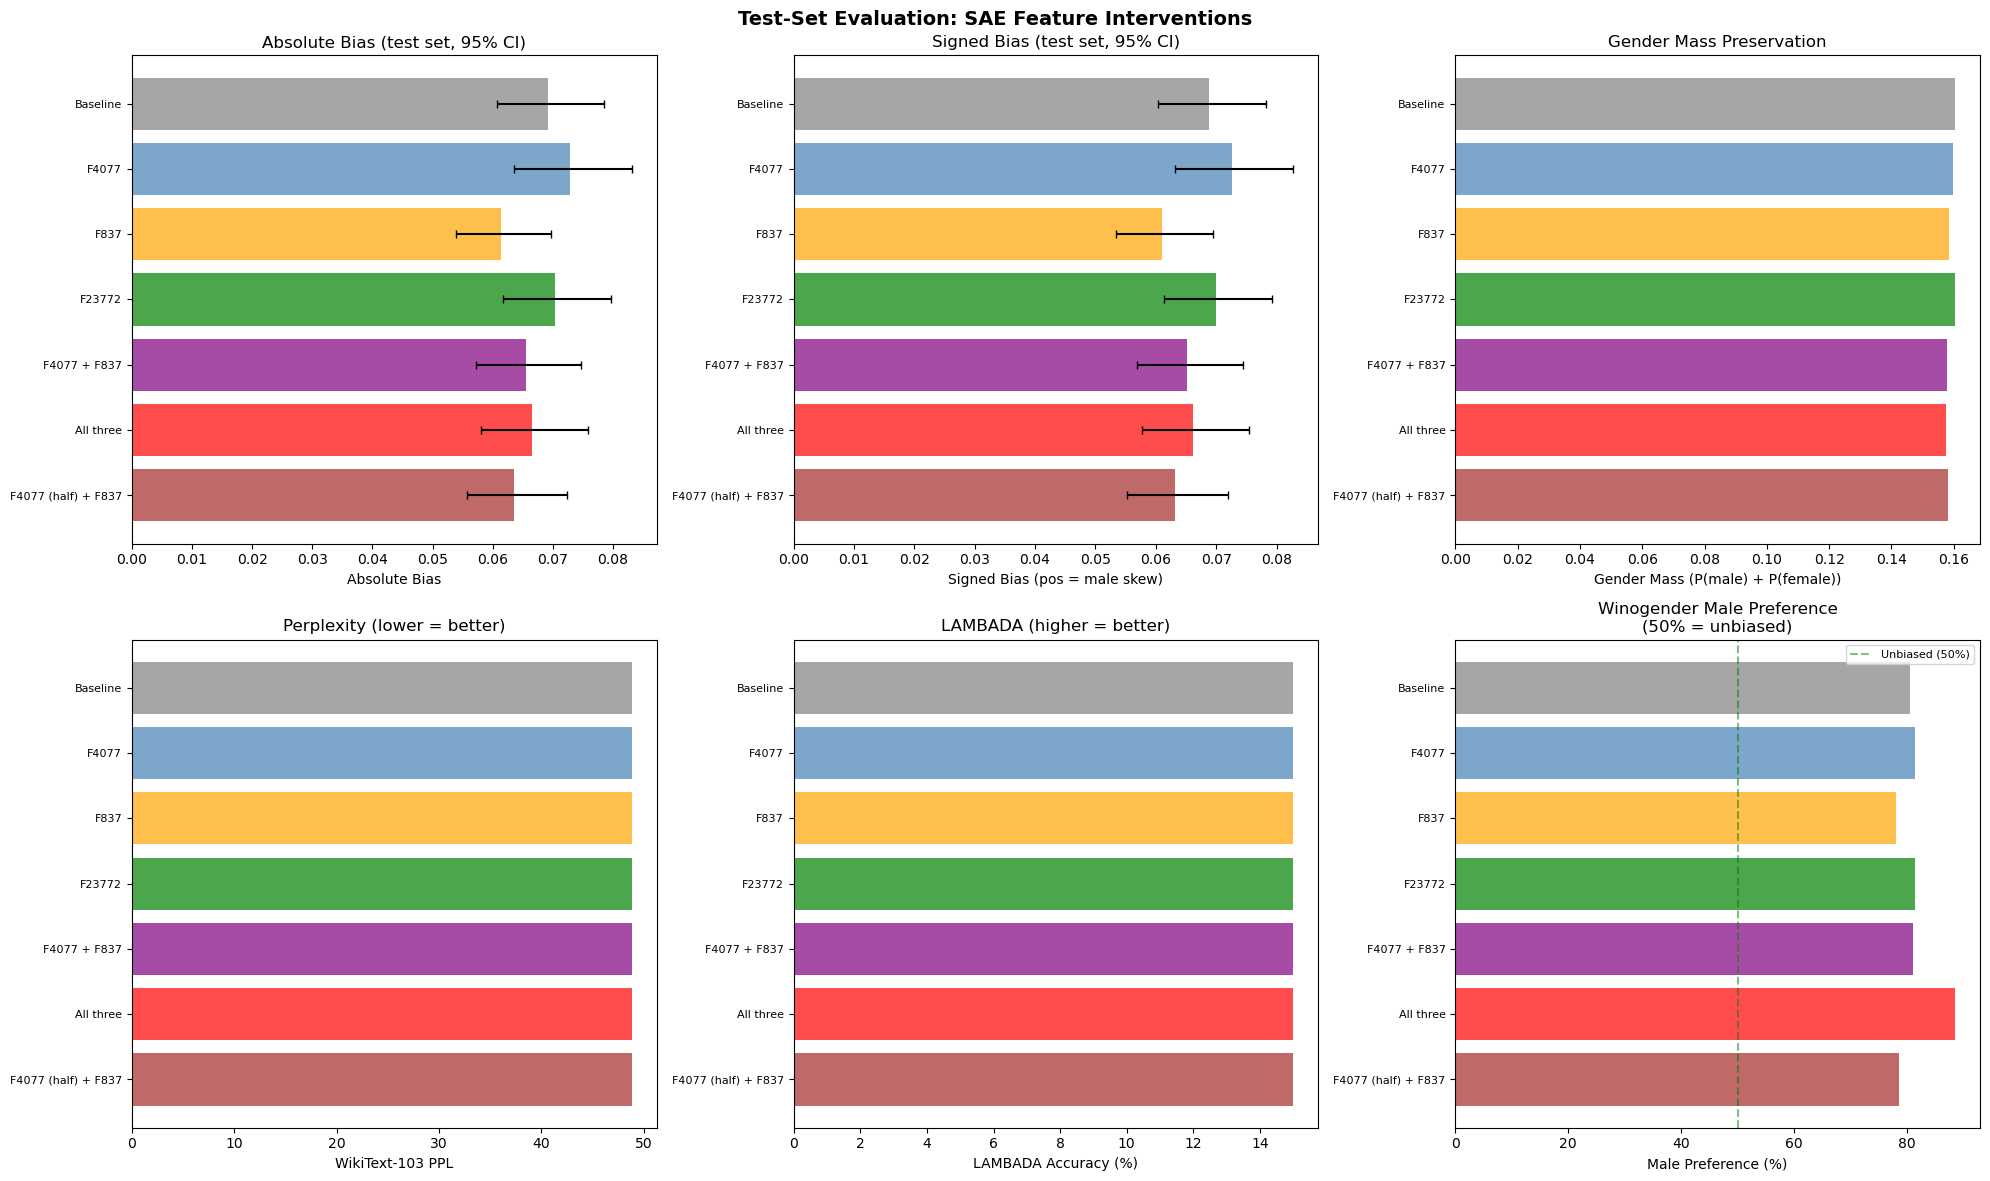

In [121]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Test-Set Evaluation: SAE Feature Interventions",
             fontsize=14, fontweight="bold")

intervention_names = list(INTERVENTIONS.keys())
colors = ["gray", "steelblue", "orange", "green", "purple", "red", "brown"]

# Plot 1: Abs bias with CIs
ax = axes[0, 0]
vals = [test_results[n]["abs_bias"] for n in intervention_names]
ci_lo = [test_results[n]["abs_bias"] - test_results[n]["abs_bias_ci"][0] for n in intervention_names]
ci_hi = [test_results[n]["abs_bias_ci"][1] - test_results[n]["abs_bias"] for n in intervention_names]
y_pos = list(range(len(intervention_names)))
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.errorbar(vals, y_pos, xerr=[ci_lo, ci_hi], fmt="none", color="black", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("Absolute Bias")
ax.set_title("Absolute Bias (test set, 95% CI)")
ax.invert_yaxis()

# Plot 2: Signed bias with CIs
ax = axes[0, 1]
vals = [test_results[n]["signed_bias"] for n in intervention_names]
ci_lo = [test_results[n]["signed_bias"] - test_results[n]["signed_bias_ci"][0] for n in intervention_names]
ci_hi = [test_results[n]["signed_bias_ci"][1] - test_results[n]["signed_bias"] for n in intervention_names]
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.errorbar(vals, y_pos, xerr=[ci_lo, ci_hi], fmt="none", color="black", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("Signed Bias (pos = male skew)")
ax.set_title("Signed Bias (test set, 95% CI)")
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.invert_yaxis()

# Plot 3: Gender mass
ax = axes[0, 2]
vals = [test_results[n]["gender_mass"] for n in intervention_names]
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("Gender Mass (P(male) + P(female))")
ax.set_title("Gender Mass Preservation")
ax.invert_yaxis()

# Plot 4: PPL
ax = axes[1, 0]
vals = [ppl_results.get(n, 0) for n in intervention_names]
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("WikiText-103 PPL")
ax.set_title("Perplexity (lower = better)")
ax.invert_yaxis()

# Plot 5: LAMBADA
ax = axes[1, 1]
vals = [lambada_results.get(n, 0) * 100 for n in intervention_names]
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("LAMBADA Accuracy (%)")
ax.set_title("LAMBADA (higher = better)")
ax.invert_yaxis()

# Plot 6: Winogender male %
ax = axes[1, 2]
vals = [winogender_results.get(n, {}).get("male_pct", 0) * 100 for n in intervention_names]
ax.barh(y_pos, vals, color=colors[:len(intervention_names)], alpha=0.7)
ax.axvline(x=50, color="green", linestyle="--", alpha=0.5, label="Unbiased (50%)")
ax.set_yticks(y_pos)
ax.set_yticklabels(intervention_names, fontsize=8)
ax.set_xlabel("Male Preference (%)")
ax.set_title("Winogender Male Preference\n(50% = unbiased)")
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("test_set_full_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [122]:
results_dir = "results/sae_male_skew"
os.makedirs(results_dir, exist_ok=True)

In [123]:
all_results = {
    "test_bias": {name: {
        "abs_bias": r["abs_bias"],
        "abs_bias_ci": r["abs_bias_ci"],
        "signed_bias": r["signed_bias"],
        "signed_bias_ci": r["signed_bias_ci"],
        "gender_mass": r["gender_mass"],
        "gender_mass_ci": r["gender_mass_ci"],
    } for name, r in test_results.items()},
    "ppl": ppl_results,
    "lambada": lambada_results,
    "blimp": {name: r.get("mean", 0) for name, r in blimp_results.items()} if blimp_results else {},
    "winogender": {name: r.get("male_pct", 0) for name, r in winogender_results.items()},
    "crows_pairs": crows_results,
    "gap": gap_results,
}

In [124]:
with open(f"{results_dir}/test_set_full_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)

In [125]:
summary_df.to_csv(f"{results_dir}/test_set_summary_table.csv", index=False)

In [ ]:
# The dev-set results demonstrate that feature-level decoupling of bias from mass suppression is possible in principle
# But the features discovered are occupation-specific rather than general, and the bias reduction doesn't fully generalise to unseen occupations
# F837 generalises better because male-stereotyped occupations may share more consistent representations
# This points to a limitation of SAE-based interventions: features may be too narrow/specific to serve as general debiasing targets